<blank>

# **Prove di random forest**

## Preparazione dei dati

---

In [1]:
import numpy as np
# Segnale su cui effettuare Train e Validation
g_0_b = np.loadtxt('data/g_0_signal_b.txt')
g_1_b = np.loadtxt('data/g_1_signal_b.txt')
# Segnale su cui effettuare Test Esterno
g_0_a = np.loadtxt('data/g_0_signal_a.txt')
g_1_a = np.loadtxt('data/g_1_signal_a.txt')

Concatenazione gruppi e vettore dei label:

In [2]:
N0, N1 = g_0_b.shape[0], g_1_b.shape[0]
# concateno g_0 e g_1
signal_b = np.vstack((g_0_b, g_1_b))
signal_a = np.vstack((g_0_a, g_1_a))

# vettore delle risposte
labels = np.concatenate((np.zeros(N0), np.ones(N1))) # uguale per A e B

## Cambio fold

---

In [5]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import cross_val_score

Prova senza PCA, con numero fold variabile tra 2 e 22

In [ ]:
acc_list = []
std_list = []

k_list = np.arange(2, 23, 1)

for k in k_list:
    rkf = RepeatedStratifiedKFold(n_splits=k, n_repeats=20, random_state=25)

    pipe = Pipeline([
        ("scaling", StandardScaler()),       
        #("reduce_dim", PCA(n_components=5, random_state=42)),
        ("classify", RFC(random_state=42)) 
    ])
    
    acc = cross_val_score(
        pipe, 
        X=signal_b, 
        y=labels, 
        cv=rkf,
        n_jobs=-1
    )
    
    m, s = acc.mean(), acc.std()
    
    print(f"k = {k}, acc = {m:.3f} ± {s:.3f}", flush=True)
    
    acc_list.append(m)
    std_list.append(s)

k = 2, acc = 0.664 ± 0.087
k = 3, acc = 0.699 ± 0.125
k = 4, acc = 0.699 ± 0.132
k = 5, acc = 0.708 ± 0.134
k = 6, acc = 0.718 ± 0.156
k = 7, acc = 0.724 ± 0.156
k = 8, acc = 0.730 ± 0.185
k = 9, acc = 0.735 ± 0.192
k = 10, acc = 0.734 ± 0.203
k = 11, acc = 0.732 ± 0.211
k = 12, acc = 0.727 ± 0.233
k = 13, acc = 0.728 ± 0.220
k = 14, acc = 0.733 ± 0.224
k = 15, acc = 0.729 ± 0.249
k = 16, acc = 0.729 ± 0.257
k = 17, acc = 0.735 ± 0.273
k = 18, acc = 0.736 ± 0.284
k = 19, acc = 0.745 ± 0.291
k = 20, acc = 0.751 ± 0.293
k = 21, acc = 0.757 ± 0.298
k = 22, acc = 0.757 ± 0.300


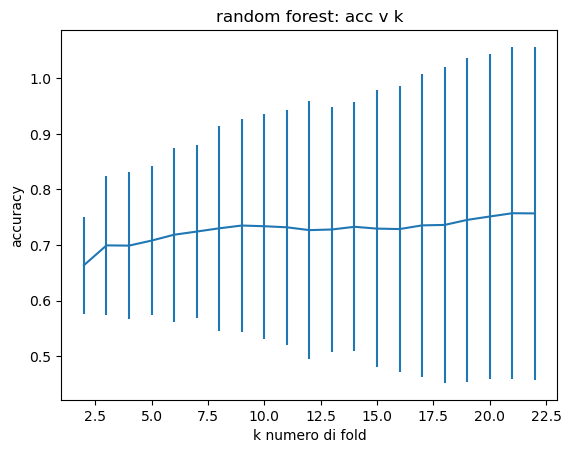

In [5]:
import matplotlib.pyplot as plt

plt.errorbar(k_list, acc_list, yerr=std_list)
plt.title('random forest: acc v k')
plt.xlabel('k numero di fold')
plt.ylabel('accuracy')
plt.show()

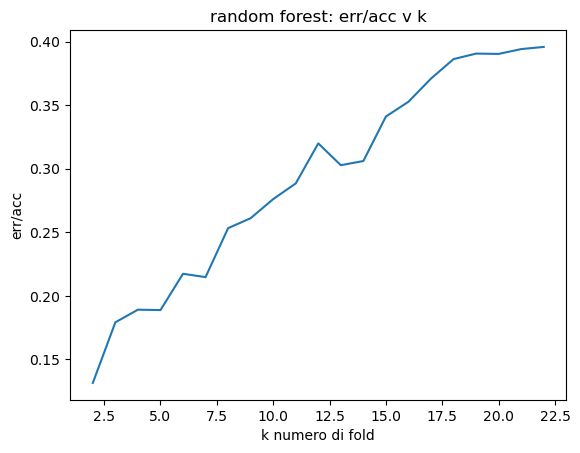

In [10]:
plt.plot(k_list, np.array(std_list)/np.array(acc_list))
plt.title('random forest: err/acc v k')
plt.xlabel('k numero di fold')
plt.ylabel('err/acc')
plt.show()

<blank>

## Grafico N estimators

In [6]:
rkf = RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42)

# ESTIMATOR
N_ESTIMATOR_OPTIONS = [30, 50, 100, 250, 500, 900, 1_000, 1500, 2_000]


# 1. Definizione Pipeline #
pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", StandardScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    #("reduce_dim", PCA(random_state=42)),
    
    # Step 3: Classificatore
    ("classify", RFC(bootstrap=True)) 
])

# 2. Definizione griglia dei parametri #
param_grid = {
    
    # Per provare parametri del classificatore
    "classify__n_estimators": N_ESTIMATOR_OPTIONS,

}

# 3. Configurazione GridSearch #
grid = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=rkf,
    n_jobs=-1, # «Number of jobs to run in parallel. -1 means using all processors»
    scoring='accuracy'
)

# 4. Training e Validation (su Segnale B) #
grid.fit(signal_b, labels)

# 5. Risultati #
print(f"La miglior configurazione: {grid.best_params_}")
print(f"Fornisce accuracy in validation: {grid.best_score_:.4f}")

# 6. Test su segnale A #
accuracy_finale = grid.score(signal_a, labels)
print(f"Risultato sul set indipendente (Segnale A): {accuracy_finale:.4f}")

La miglior configurazione: {'classify__n_estimators': 900}
Fornisce accuracy in validation: 0.7321
Risultato sul set indipendente (Segnale A): 0.4545


In [7]:
import pandas as pd
results_df = pd.DataFrame(grid.cv_results_)

columns_to_show = [ 
    'param_classify__n_estimators', 
    'mean_test_score', 
    'std_test_score', 
    'rank_test_score'
]

In [ ]:
# accuracy vs n_estimators
x = N_ESTIMATOR_OPTIONS
y = results_df['mean_test_score']
yerr = results_df['std_test_score']

plt.errorbar(x,y, yerr=yerr)
plt.title('random forest')
plt.xlabel('N estimators')
plt.ylabel('accuracy')
plt.show()

NameError: name 'results_df' is not defined

## N estimators al variare di K fold

richiesta apparentemente senza senso della prof

In [6]:
acc_dict = {}
std_dict = {}

k_list = np.arange(2, 23, 1)
N_ESTIMATOR_OPTIONS = [50, 100, 250, 500, 1_000]

for k in k_list:
    acc_dict[k] = []
    std_dict[k] = []
    n_repeats = 10 if k < 16 else 5 
    rkf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=25)
    print(f"- k={k}")
    
    for N_e in N_ESTIMATOR_OPTIONS:

        pipe = Pipeline([
            ("scaling", StandardScaler()),       
            #("reduce_dim", PCA(n_components=5, random_state=42)),
            ("classify", RFC(n_estimators=N_e, bootstrap=True, random_state=42)) 
        ])
        
        acc = cross_val_score(
            pipe, 
            X=signal_b, 
            y=labels, 
            cv=rkf,
            n_jobs=-1
        )
        
        m, s = acc.mean(), acc.std()
        
        print(f"   • N_e = {N_e}, acc = {m:.3f} ± {s:.3f}", flush=True)
        
        acc_dict[k].append(m)
        std_dict[k].append(s)

- k=2


   • N_e = 50, acc = 0.641 ± 0.073
   • N_e = 100, acc = 0.659 ± 0.093
   • N_e = 250, acc = 0.686 ± 0.084
   • N_e = 500, acc = 0.705 ± 0.087
   • N_e = 1000, acc = 0.691 ± 0.103
- k=3
   • N_e = 50, acc = 0.685 ± 0.125
   • N_e = 100, acc = 0.724 ± 0.119
   • N_e = 250, acc = 0.723 ± 0.114
   • N_e = 500, acc = 0.714 ± 0.111
   • N_e = 1000, acc = 0.714 ± 0.112
- k=4
   • N_e = 50, acc = 0.691 ± 0.116
   • N_e = 100, acc = 0.714 ± 0.134
   • N_e = 250, acc = 0.723 ± 0.113
   • N_e = 500, acc = 0.720 ± 0.106
   • N_e = 1000, acc = 0.723 ± 0.115
- k=5
   • N_e = 50, acc = 0.712 ± 0.149
   • N_e = 100, acc = 0.701 ± 0.142
   • N_e = 250, acc = 0.722 ± 0.127
   • N_e = 500, acc = 0.736 ± 0.122
   • N_e = 1000, acc = 0.731 ± 0.117
- k=6
   • N_e = 50, acc = 0.711 ± 0.146
   • N_e = 100, acc = 0.718 ± 0.147
   • N_e = 250, acc = 0.738 ± 0.131
   • N_e = 500, acc = 0.726 ± 0.142
   • N_e = 1000, acc = 0.743 ± 0.134
- k=7
   • N_e = 50, acc = 0.719 ± 0.164
   • N_e = 100, acc = 0.712 ± 0.172

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Creiamo il DataFrame: le chiavi del dizionario (k) diventano le colonne
# L'indice (le righe) sarà la lista degli stimatori che hai usato
df_acc = pd.DataFrame(acc_dict, index=N_ESTIMATOR_OPTIONS)

# Rinominiamo gli assi per chiarezza
df_acc.index.name = "N Estimators"
df_acc.columns.name = "k Folds"

heatmap

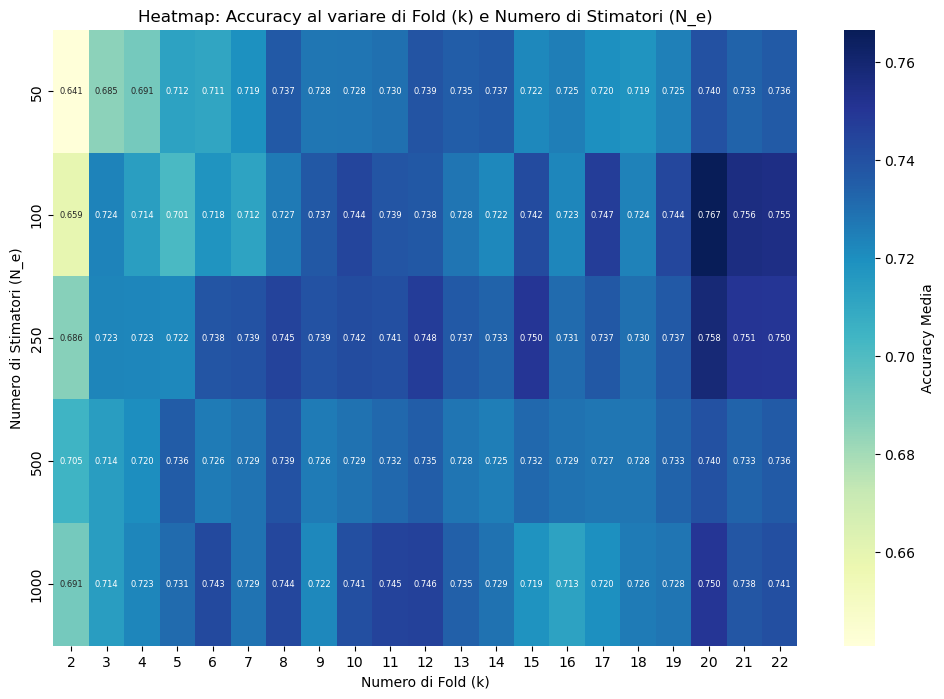

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_acc, 
    annot=True,      # Scrive il valore dell'accuracy dentro ogni cella
    fmt=".3f",       # Formato a 3 decimali
    cmap="YlGnBu",   # Colormap dal giallo (basso) al blu (alto)
    cbar_kws={'label': 'Accuracy Media'},
    annot_kws={"size": 6}
)

plt.title("Heatmap: Accuracy al variare di Fold (k) e Numero di Stimatori (N_e)")
plt.xlabel("Numero di Fold (k)")
plt.ylabel("Numero di Stimatori (N_e)")
plt.show()

In [ ]:
"""- k=2
   • N_e = 30, acc = 0.611 ± 0.083
   • N_e = 50, acc = 0.639 ± 0.086
   • N_e = 100, acc = 0.664 ± 0.087
   • N_e = 250, acc = 0.686 ± 0.079
   • N_e = 500, acc = 0.689 ± 0.083
   • N_e = 900, acc = 0.684 ± 0.083
   • N_e = 1000, acc = 0.682 ± 0.089
   • N_e = 1500, acc = 0.681 ± 0.084
   • N_e = 2000, acc = 0.683 ± 0.080
- k=3
   • N_e = 30, acc = 0.661 ± 0.124
   • N_e = 50, acc = 0.675 ± 0.123
   • N_e = 100, acc = 0.699 ± 0.125
   • N_e = 250, acc = 0.702 ± 0.119
   • N_e = 500, acc = 0.695 ± 0.115
   • N_e = 900, acc = 0.697 ± 0.115
   • N_e = 1000, acc = 0.698 ± 0.112
   • N_e = 1500, acc = 0.695 ± 0.108
   • N_e = 2000, acc = 0.697 ± 0.114
- k=4
   • N_e = 30, acc = 0.672 ± 0.136
   • N_e = 50, acc = 0.680 ± 0.117
   • N_e = 100, acc = 0.699 ± 0.132
   • N_e = 250, acc = 0.708 ± 0.114
   • N_e = 500, acc = 0.707 ± 0.108
   • N_e = 900, acc = 0.708 ± 0.114
   • N_e = 1000, acc = 0.708 ± 0.117
   • N_e = 1500, acc = 0.703 ± 0.116
   • N_e = 2000, acc = 0.697 ± 0.119
- k=5
   • N_e = 30, acc = 0.696 ± 0.134
   • N_e = 50, acc = 0.701 ± 0.139
   • N_e = 100, acc = 0.708 ± 0.134
   • N_e = 250, acc = 0.721 ± 0.128
   • N_e = 500, acc = 0.724 ± 0.122
   • N_e = 900, acc = 0.719 ± 0.118
   • N_e = 1000, acc = 0.723 ± 0.117
   • N_e = 1500, acc = 0.721 ± 0.122
   • N_e = 2000, acc = 0.725 ± 0.120
- k=6
   • N_e = 30, acc = 0.678 ± 0.173
   • N_e = 50, acc = 0.716 ± 0.156
   • N_e = 100, acc = 0.718 ± 0.156
   • N_e = 250, acc = 0.732 ± 0.148
   • N_e = 500, acc = 0.725 ± 0.150
   • N_e = 900, acc = 0.735 ± 0.145
   • N_e = 1000, acc = 0.742 ± 0.145
   • N_e = 1500, acc = 0.732 ± 0.149
   • N_e = 2000, acc = 0.728 ± 0.147
- k=7
   • N_e = 30, acc = 0.676 ± 0.148
   • N_e = 50, acc = 0.722 ± 0.154
   • N_e = 100, acc = 0.724 ± 0.156
   • N_e = 250, acc = 0.733 ± 0.154
   • N_e = 500, acc = 0.723 ± 0.151
   • N_e = 900, acc = 0.723 ± 0.152
   • N_e = 1000, acc = 0.722 ± 0.152
   • N_e = 1500, acc = 0.731 ± 0.151
   • N_e = 2000, acc = 0.731 ± 0.153
- k=8
   • N_e = 30, acc = 0.673 ± 0.191
   • N_e = 50, acc = 0.712 ± 0.186
   • N_e = 100, acc = 0.730 ± 0.185
   • N_e = 250, acc = 0.737 ± 0.181
   • N_e = 500, acc = 0.731 ± 0.177
   • N_e = 900, acc = 0.735 ± 0.180
   • N_e = 1000, acc = 0.735 ± 0.177
   • N_e = 1500, acc = 0.741 ± 0.176
   • N_e = 2000, acc = 0.731 ± 0.178
- k=9
   • N_e = 30, acc = 0.686 ± 0.202
   • N_e = 50, acc = 0.722 ± 0.189
   • N_e = 100, acc = 0.735 ± 0.192
   • N_e = 250, acc = 0.735 ± 0.174
   • N_e = 500, acc = 0.726 ± 0.181
   • N_e = 900, acc = 0.724 ± 0.181
   • N_e = 1000, acc = 0.723 ± 0.183
   • N_e = 1500, acc = 0.724 ± 0.183
   • N_e = 2000, acc = 0.726 ± 0.184
- k=10
   • N_e = 30, acc = 0.704 ± 0.208
   • N_e = 50, acc = 0.728 ± 0.200
   • N_e = 100, acc = 0.734 ± 0.203
   • N_e = 250, acc = 0.738 ± 0.182
   • N_e = 500, acc = 0.727 ± 0.187
   • N_e = 900, acc = 0.730 ± 0.183
   • N_e = 1000, acc = 0.733 ± 0.186
   • N_e = 1500, acc = 0.737 ± 0.183
   • N_e = 2000, acc = 0.743 ± 0.187
- k=11
   • N_e = 30, acc = 0.701 ± 0.215
   • N_e = 50, acc = 0.728 ± 0.206
   • N_e = 100, acc = 0.732 ± 0.211
   • N_e = 250, acc = 0.740 ± 0.207
   • N_e = 500, acc = 0.726 ± 0.207
   • N_e = 900, acc = 0.735 ± 0.204
   • N_e = 1000, acc = 0.736 ± 0.207
   • N_e = 1500, acc = 0.741 ± 0.203
   • N_e = 2000, acc = 0.745 ± 0.206
- k=12
   • N_e = 30, acc = 0.693 ± 0.232
   • N_e = 50, acc = 0.727 ± 0.225
   • N_e = 100, acc = 0.727 ± 0.233
   • N_e = 250, acc = 0.744 ± 0.227
   • N_e = 500, acc = 0.729 ± 0.220
   • N_e = 900, acc = 0.736 ± 0.221"""